installation bibliothèques

In [1]:
# 📦 Importation des bibliothèques

import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import re
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import random
import os
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

Importation CSV

In [4]:
# 📂 Chargement des données

y_test=pd.read_csv ("test_filtered.csv", sep=",")

In [6]:
# 📂 Chargement des données

y_val=pd.read_csv ("val_filtered.csv", sep=",")

In [8]:
# 📂 Chargement des données
# 👉 Description automatique ajoutée
y_train = pd.read_csv ("train_filtered.csv", sep=",")

importation images

In [19]:
# 📌 Bloc de code

ls "C:\Users\sofia\Rakuten\Nettoyage\images_bis"

 Le volume dans le lecteur C s’appelle Windows
 Le numéro de série du volume est E2D4-17F3

 Répertoire de C:\Users\sofia\Rakuten\Nettoyage\images_bis

14/03/2025  00:41    <DIR>          .
14/03/2025  00:41    <DIR>          ..
14/03/2025  00:31    <DIR>          .ipynb_checkpoints
14/03/2025  00:41           156 678 Processing image.ipynb
13/03/2025  19:30            14 009 Test.ipynb
14/03/2025  00:39    <DIR>          test_bis
13/03/2025  17:56             7 753 test_filtered.csv
14/03/2025  00:38    <DIR>          train_bis
13/03/2025  17:56            78 451 train_filtered.csv
14/03/2025  00:39    <DIR>          val_bis
13/03/2025  17:56             7 737 val_filtered.csv
               5 fichier(s)          264 628 octets
               6 Rép(s)  147 061 940 224 octets libres


In [10]:

# 📂 Définition des chemins des dossiers
base_dir = r"C:\Users\sofia\Rakuten\Nettoyage\images_bis"
sub_dirs = ["train_bis", "test_bis", "val_bis"]


# 🏷 Encodage des labels
label_encoder = LabelEncoder()
y_train["prdtypecode"] = label_encoder.fit_transform(y_train["prdtypecode"])
y_test["prdtypecode"] = label_encoder.transform(y_test["prdtypecode"])
y_val["prdtypecode"] = label_encoder.transform(y_val["prdtypecode"])

# 📏 Paramètres
IMG_SIZE = (224, 224)  # Taille standard pour le CNN
BATCH_SIZE = 32  # Taille des lots

# 📥 Fonction pour charger les images avec barre de progression
def load_images_and_labels(dataframe, folder):
    images = []
    labels = []
    folder_path = os.path.join(base_dir, folder)
    
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f"🔄 Chargement {folder}"):
        filename = f"image_{row['filename']}_product_*.jpg"  # Motif du nom de fichier
        image_files = [f for f in os.listdir(folder_path) if f.startswith(f"image_{row['filename']}_product_")]
        
        if image_files:
            img_path = os.path.join(folder_path, image_files[0])
            img = load_img(img_path, target_size=IMG_SIZE)
            img_array = img_to_array(img) / 255.0  # Normalisation
            images.append(img_array)
            labels.append(row["prdtypecode"])
    
    return np.array(images), np.array(labels)

# 📥 Chargement des images et labels avec la barre de progression
X_train, y_train = load_images_and_labels(y_train, "train_bis")
X_test, y_test = load_images_and_labels(y_test, "test_bis")
X_val, y_val = load_images_and_labels(y_val, "val_bis")

# 📌 Vérification des formes des données
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")
print(f"Val: {X_val.shape}, Labels: {y_val.shape}")


🔄 Chargement val_bis: 100%|██████████| 500/500 [00:15<00:00, 33.11it/s]


Train: (5000, 224, 224, 3), Labels: (5000,)
Test: (500, 224, 224, 3), Labels: (500,)
Val: (500, 224, 224, 3), Labels: (500,)


Encodage Labels :

entrainement modèle 

C:\Users\sofia\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1326 - loss: 2.9122
Epoch 1: val_loss improved from inf to 2.51834, saving model to best_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.1329 - loss: 2.9111 - val_accuracy: 0.2740 - val_loss: 2.5183 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2762 - loss: 2.4880
Epoch 2: val_loss improved from 2.51834 to 2.33593, saving model to best_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.2764 - loss: 2.4875 - val_accuracy: 0.3260 - val_loss: 2.3359 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3628 - loss: 2.2473
Epoch 3: val_loss improved from 2.33593 to 2.20404, saving model to best_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.3629 - loss: 2.2469 - val_accuracy: 0.3760 - val_loss: 2.2040 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4000 - loss: 2.0921
Epoch 4: val_loss improved from 2.20404 to 2.11779, saving model to best_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.4001 - loss: 2.0917 - val_accuracy: 0.3860 - val_loss: 2.1178 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4372 - loss: 1.9107
Epoch 5: val_loss improved from 2.11779 to 2.01055, saving model to best_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.4373 - loss: 1.9104 - val_accuracy: 0.4020 - val_loss: 2.0106 - learning_rate: 0.0010
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4691 - loss: 1.7574
Epoch 6: val_loss did not improve from 2.01055
157/157 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.4691 - loss: 1.7571 - val_accuracy: 0.3860 - val_loss: 2.0860 - learning_rate: 0.0010
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4949 - loss: 1.6709
Epoch 7: val_loss did not improve from 2.01055
157/157 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.4950 - loss: 1.6705 - val_accuracy: 0.3740 - val_loss: 2.2892 - learning_rate: 0.0010
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5124 - loss: 1.5390
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: val_loss did not improve from 2.01055
157/157 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.5126 - loss: 1.5387 - val_accuracy: 0.4040 - 

C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📊 Train Metrics:
✅ Accuracy: 0.5396
✅ F1-score: 0.4778
🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.65      0.59       246
           1       0.70      0.84      0.76       425
           2       1.00      0.01      0.02        99
           3       0.00      0.00      0.00         9
           4       0.49      0.65      0.56       467
           5       0.77      0.84      0.80       418
           6       0.91      0.20      0.33       103
           7       0.67      0.02      0.04       198
           8       0.27      0.07      0.11       116
           9       0.71      0.05      0.09       110
          10       1.00      0.09      0.16        45
          11       0.00      0.00      0.00        47
          12       0.50      0.03      0.06       201
          13       0.00      0.00      0.00        14
          14       0.00      0.00      0.00        16
          15       0.00      0.00      0.00        23


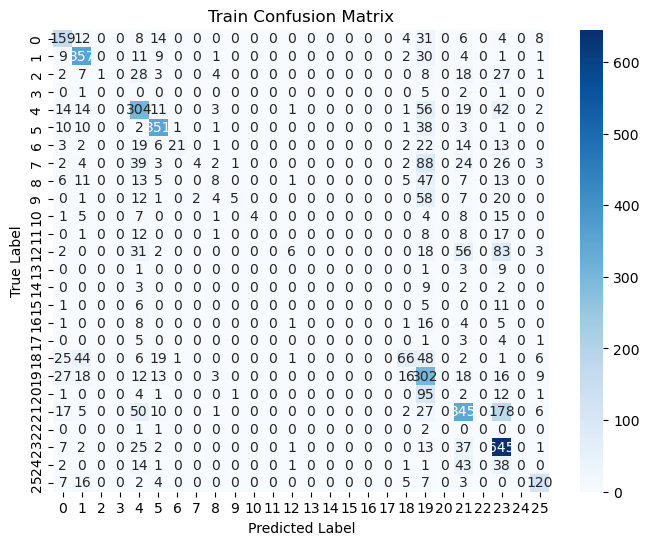

C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklea


📊 Validation Metrics:
✅ Accuracy: 0.4020
✅ F1-score: 0.3590
🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.26      0.33        61
           1       0.64      0.70      0.67        73
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         1
           4       0.19      0.28      0.23        25
           5       0.60      0.75      0.67        55
           6       0.00      0.00      0.00         6
           7       0.00      0.00      0.00        24
           8       0.00      0.00      0.00        15
           9       0.00      0.00      0.00        13
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00         5
          12       0.00      0.00      0.00        12
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         3
          15       0.00      0.00      0.00      

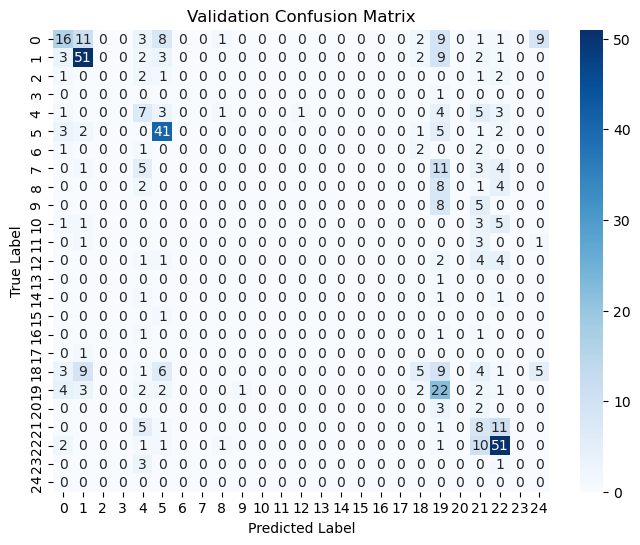

C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklea


📊 Test Metrics:
✅ Accuracy: 0.4120
✅ F1-score: 0.3792
🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.38      0.46        53
           1       0.71      0.73      0.72        73
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00         1
           4       0.19      0.32      0.24        25
           5       0.67      0.72      0.69        67
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00        23
           8       0.00      0.00      0.00        12
           9       0.00      0.00      0.00        17
          10       0.00      0.00      0.00        17
          11       0.00      0.00      0.00         7
          12       0.00      0.00      0.00        13
          13       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         4
 

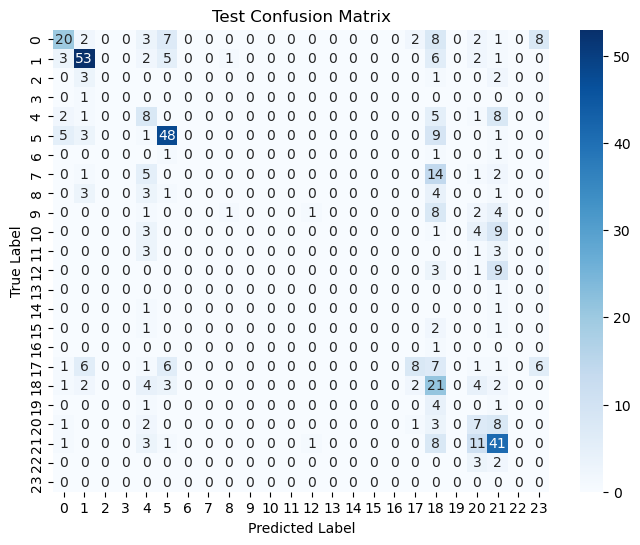

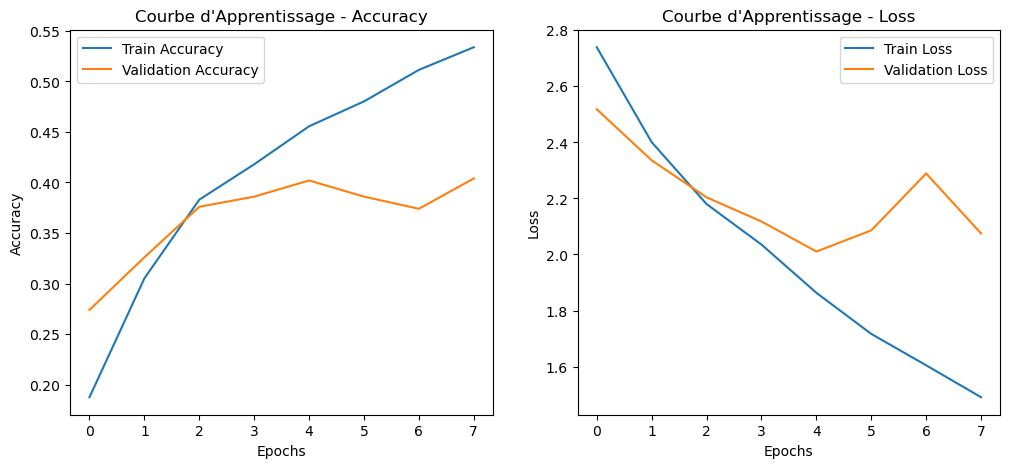

In [12]:

# 📌 Fixer le seed pour assurer la reproductibilité
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 📌 Définir le nombre de classes du dataset
NUM_CLASSES = 27  # Ajuste ce nombre selon ton dataset

# 📌 Vérifier et encoder les labels si nécessaire
if len(y_train.shape) == 1:
    y_train = to_categorical(y_train, NUM_CLASSES)
    y_val = to_categorical(y_val, NUM_CLASSES)
    y_test = to_categorical(y_test, NUM_CLASSES)

# 📌 Définition du modèle CNN amélioré

model = Sequential([
    # Couche 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    # Couche 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Couche 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Couche 4 (nouvelle couche ajoutée)
    Conv2D(256, (3, 3), activation='relu'),    
    MaxPooling2D(2, 2),

    # Couches fully connected
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

# 📌 Compilation du modèle
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 📌 Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, verbose=1)

# 📌 Entraînement du modèle
history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=32, 
    validation_data=(X_val, y_val), 
    callbacks=[early_stopping, lr_scheduler, checkpoint]
)

# 📌 Prédictions sur Train, Validation et Test
y_train_pred = model.predict(X_train)
y_train_pred_classes = np.argmax(y_train_pred, axis=1)
y_train_true_classes = np.argmax(y_train, axis=1)

y_val_pred = model.predict(X_val)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true_classes = np.argmax(y_val, axis=1)

y_test_pred = model.predict(X_test)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true_classes = np.argmax(y_test, axis=1)

# 📌 Calcul des métriques pour chaque dataset
def compute_metrics(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)

    print(f"\n📊 {dataset_name} Metrics:")
    print(f"✅ Accuracy: {accuracy:.4f}")
    print(f"✅ F1-score: {f1:.4f}")
    print(f"🔍 Classification Report:\n{report}")

    # Matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.show()

# 📌 Affichage des métriques pour Train, Validation et Test
compute_metrics(y_train_true_classes, y_train_pred_classes, "Train")
compute_metrics(y_val_true_classes, y_val_pred_classes, "Validation")
compute_metrics(y_test_true_classes, y_test_pred_classes, "Test")

# 📌 Courbes d'entraînement
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Courbe d\'Apprentissage - Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Courbe d\'Apprentissage - Loss')

plt.show()



In [ ]:
# 📌 Bloc de code
# 👉 Description automatique ajoutée
